# HSSM in thirty minutes

**Day 3, 09:30 — 30 minutes.** Alexander Fengler.

<img src="../../images/logos/hssm-logo.png" alt="HSSM logo"
     style="display:block; margin:0.5rem auto 1.5rem auto; width:240px">

Yesterday at 12:00 you saw **bambi**: write `"y ~ 1 + x"`, and it builds the
PyMC model, chooses priors, fits, and predicts at new covariates. At 14:30
you dropped a DDM likelihood into PyMC by hand and wrote `v[coh_idx]` to make
drift depend on condition.

**HSSM is what you get when you combine those two ideas.** It is a formula
interface — built on bambi — for models whose likelihood is a
sequential-sampling model rather than a Gaussian. The extra axes of
flexibility it adds over bambi are:

| | bambi | HSSM |
|---|---|---|
| likelihood | GLM families | **DDM, LBA, race, collapsing-bound, …** |
| what a formula acts on | parameters of the family | **translates to any SSM parameter** — drift, boundary, bias, non-decision time |
| where the likelihood comes from | closed form | closed form, a **neural approximation**, or your own function |
| extras features | — | native lapse processes, proprietary plots, "surrogate -> PyMC RV" constructors |


<details class="sbi-note">
<summary>▶️ <b>Running this on Google Colab</b></summary>

The cell below is a no-op on your own machine. On Colab it installs the stack
and downloads the shared helper module, which lives one directory up in the
repository and is therefore not importable there.

Expect the install to take a few minutes. If Colab asks you to restart the
runtime, do it and then run the cell again — the second run is a no-op.

</details>

In [1]:
# --- Google Colab bootstrap; does nothing anywhere else ---------------------
import importlib.util, subprocess, sys, urllib.error, urllib.request

IN_COLAB = importlib.util.find_spec("google.colab") is not None

# `main` once this is merged; the branch is the fallback so the Colab path can
# be tested BEFORE the merge, when main does not yet have these files.
_REFS = ("main", "afengler.tutorials")
_RAW = "https://raw.githubusercontent.com/stefanradev93/sbi4cogsci/{ref}/tutorials/"


def _fetch(module):
    for ref in _REFS:
        try:
            urllib.request.urlretrieve(_RAW.format(ref=ref) + module, module)
            return ref
        except urllib.error.HTTPError:
            continue
    raise RuntimeError(f"could not fetch {module} from any of {_REFS}")


if IN_COLAB:
    # numba>=0.61 is REQUIRED, not cosmetic. pytensor resolves linker="auto" to
    # its numba backend, and numba renamed FunctionModel's first field
    # addr -> c_addr in 0.61. Colab preinstalls an older numba, and pytensor
    # declares numba only as an optional extra, so pip leaves it in place and
    # any MvNormal (SolveTriangular has no C implementation) dies with
    # KeyError: "FunctionModel does not have a field named 'c_addr'".
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "numba>=0.61", "pymc>=6.2", "arviz>=1.2", "hssm>=0.4"],
                   check=True)
    # `dot` is a system binary, not a Python package.
    subprocess.run(["apt-get", "-qq", "install", "-y", "graphviz"],
                   check=True)
    for _mod in ["sbi4cogsci_style.py"]:
        print(f"  fetched {_mod} from {_fetch(_mod)}")
    print("Colab setup done.")

In [2]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # -> tutorials/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import hssm
import sbi4cogsci_style as S

S.use()
warnings.filterwarnings("ignore")

RANDOM_SEED = sum(map(ord, "sbi4cogsci-hssm"))
rng = np.random.default_rng(RANDOM_SEED)
PARAMS = ["v", "a", "z", "t"]

print("hssm", hssm.__version__, "|", len(hssm.list_models()), "built-in models")

hssm 0.4.0 | 16 built-in models


## 1. A dataset whose truth we know

We could load a real dataset. Instead we **build one from a known model**, so
that every claim about recovery later is checkable rather than rhetorical.

The design is modelled on `cavanagh_theta`, the classic dataset shipped with
HSSM: participants, a trial-level covariate, and a condition.

The generative model is

$$
v_i = \beta^v_0 + \beta^v_1\, \mathbb{1}[\text{cond}_i = \text{"hard"}],
\qquad
a_i = \beta^a_0 + \beta^a_1\, \text{theta}_i,
$$

with $z$ and $t$ fixed. **Difficulty acts on the drift** — a harder stimulus
supplies weaker evidence — and **theta acts on the boundary**.

That assignment is a modelling claim, not a convenience, and it is worth two
sentences. It matches the finding the `cavanagh_theta` dataset is famous for:
mediofrontal theta tracks the **decision threshold**, not the rate of evidence
accumulation. It also makes the two manipulations *visibly different*: drift
moves accuracy and RT together, boundary trades them off. You will see exactly
that in the fit checks below, and the exercise at the end asks what happens
when you assign them the other way round.

In [3]:
N_TRIALS = 1200
theta_cov = rng.normal(0.0, 1.0, N_TRIALS)               # trial-level covariate
cond = rng.choice(["easy", "hard"], N_TRIALS)

scaffold = hssm.simulate_data("ddm", [0.5, 1.5, 0.5, 0.3], N_TRIALS,
                              random_state=RANDOM_SEED)
scaffold["theta"] = theta_cov
scaffold["cond"] = cond

# The generating model. p_outlier=None so the synthetic data contains no
# lapses; center_predictors=False so an Intercept means "the value at 0".
gen_model = hssm.HSSM(
    data=scaffold, model="ddm",
    include=[{"name": "v", "formula": "v ~ 1 + C(cond)"},
             {"name": "a", "formula": "a ~ 1 + theta"}],
    p_outlier=None, center_predictors=False,
)

# Every free parameter must be pinned, and each value must match that
# parameter's SHAPE. Categorical contrasts are vectors even when there is only
# one of them — `v_C(cond)` has shape (1,), so it takes [-0.4], not -0.4.
#
# The two drift values are chosen to land both conditions in the 15-35% error
# band that yesterday afternoon identified as the well-conditioned regime:
# easy ends up near 14% errors, hard near 36%.
TRUE = {
    "v_Intercept": 0.6,      # drift in the "easy" condition
    "v_C(cond)": [-0.4],     # how much WEAKER the evidence is when "hard"
    "a_Intercept": 1.5,      # boundary at theta = 0
    "a_theta": 0.3,          # boundary per unit of theta
    "z": 0.5,
    "t": 0.30,
}
print("free parameters and their shapes:")
for rv, val in gen_model.pymc_model.initial_point().items():
    print(f"   {rv:24s} {val.shape}")

# `sample_do` pins every free parameter to a chosen value and draws from the
# resulting model — the do-operator you met yesterday, used generatively.
dt = gen_model.sample_do(TRUE, draws=1, random_seed=RANDOM_SEED)
sim = dt["prior_predictive"]["rt,response"].values[0, 0]     # (N_TRIALS, 2)

data = pd.DataFrame(sim, columns=["rt", "response"])
data["theta"] = theta_cov
data["cond"] = cond
data["participant_id"] = rng.integers(0, 12, N_TRIALS)       # for section 6

print(data.head().to_string(index=False))
print(f"\n{len(data)} trials | error rate {(data['response'] == -1).mean():.1%}")

Model initialized successfully.


Sampling: [rt,response]


free parameters and their shapes:
   t_log__                  ()
   z_interval__             ()
   v_Intercept              ()
   v_C(cond)                (1,)
   a_Intercept_interval__   ()
   a_theta                  ()


      rt  response     theta cond  participant_id
2.453736       1.0  1.293487 hard               4
1.036704       1.0 -0.930231 hard              11
2.971241       1.0 -0.313631 easy              10
2.307350       1.0  0.472591 easy              10
9.768160       1.0  0.424181 hard               0

1200 trials | error rate 25.2%


<details class="sbi-key" open>
<summary>🔑 <b>Response coding in HSSM is <code>-1</code> / <code>+1</code></b></summary>

Two-choice models expect responses coded `-1` and `+1`. You never have to
guess this — every model declares it:

```python
hssm.config.model_config["ddm"]["choices"]   ->  [-1, 1]
```

Multi-alternative models use `[0 … K-1]` instead, and declare that the same
way. Check the config rather than assuming.

</details>

In [4]:
from ssms.config import model_config
for name in ["ddm", "angle", "lba3", "race_no_bias_angle_4"]:
    print(f"  {name:22s} choices = {model_config[name]['choices']}")

  ddm                    choices = [-1, 1]
  angle                  choices = [-1, 1]
  lba3                   choices = [0, 1, 2]
  race_no_bias_angle_4   choices = [0, 1, 2, 3]


## 2. The shortest model that works

One line for the model, one for the fit.

In [5]:
model_flat = hssm.HSSM(data=data, model="ddm")
print(model_flat)

Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 1200

Parameters:

v:
    Prior: Normal(mu: 0.0, sigma: 2.0)
    Explicit bounds: (-inf, inf)

a:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)

z:
    Prior: Uniform(lower: 0.0, upper: 1.0)
    Explicit bounds: (0.0, 1.0)

t:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 20.0)


`print(model)` resolves and shows every prior, every bound, the links, and the
lapse process. Read it before sampling, every time.

The graph shows the same thing structurally:

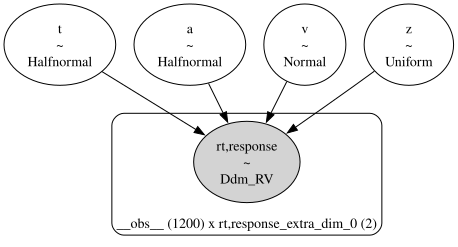

In [6]:
model_flat.graph()

In [7]:
model_flat.sample(draws=500, tune=500, chains=2, cores=1,
                  random_seed=RANDOM_SEED, progressbar=False)
print(az.summary(model_flat.traces, var_names=PARAMS, kind="stats").to_string())

Using default initvals. 



Initializing NUTS using adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [t, a, z, v]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 7 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


   mean     sd eti89_lb eti89_ub
v   0.4  0.027     0.36     0.44
a   1.5  0.024      1.4      1.5
z  0.49  0.011     0.47     0.51
t  0.23  0.019      0.2     0.26


## 3. `p_outlier`: the lapse process

Notice the last line of `print(model)`: **`Lapse probability: 0.05`**. Every
HSSM model carries one unless you say otherwise, and it is worth
understanding rather than merely knowing about.

Real response-time data contains trials the model did not generate — button
mashing, attention lapses, a sneeze. Those trials have RTs the SSM considers
nearly impossible, and because the likelihood is a *product* over trials, one
impossible trial can dominate the entire fit.

HSSM's answer is a mixture. With lapse probability $p$ and lapse density
$f_{\text{lapse}}$,

$$
f_{\text{eff}}(\text{rt}) \;=\; (1-p)\, f_{\text{SSM}}(\text{rt}) \;+\; p\, f_{\text{lapse}}(\text{rt}),
$$

with $f_{\text{lapse}}$ defaulting to $\text{Uniform}(0, 20)$. The effect is a
**floor**: no observation can ever be more surprising than $\log(p/20)$.

In [8]:
import pymc as pm

probe = pd.DataFrame({"rt": [0.9, 0.31, 18.0], "response": [1.0, 1.0, -1.0]})
THETA = dict(v=2.0, a=2.5, z=0.5, t=0.3)

m_on = hssm.HSSM(data=probe, model="ddm", p_outlier=0.05, a=2.5, z=0.5, t=0.3)
m_off = hssm.HSSM(data=probe, model="ddm", p_outlier=None, a=2.5, z=0.5, t=0.3)

obs = probe[["rt", "response"]].to_numpy()
lp_off = pm.logp(m_off.model_distribution.dist(**THETA), obs).eval()
lp_on = pm.logp(m_on.model_distribution.dist(**THETA, p_outlier=0.05), obs).eval()

print(f"{'rt':>7} {'no lapse':>12} {'with lapse':>12}")
for r, off, on in zip(probe["rt"], lp_off, lp_on):
    print(f"{r:7.2f} {off:12.2f} {on:12.2f}")
print(f"\nthe floor is log(p/20) = {np.log(0.05 / 20):.3f}")

Model initialized successfully.


Model initialized successfully.


     rt     no lapse   with lapse
   0.90        -0.64        -0.69
   0.31       -64.34        -5.99
  18.00       -45.97        -5.99

the floor is log(p/20) = -5.991


The typical trial barely moves. The impossibly fast one (`rt` below the
non-decision time, so the SSM says it *cannot happen*) goes from $-64$ to the
floor, and the very slow one likewise. Draw it:

Model initialized successfully.


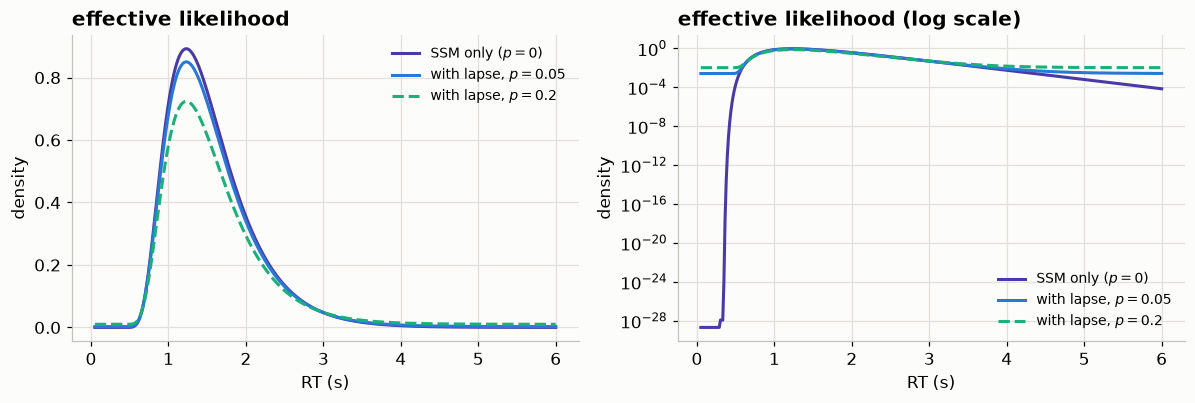

In [9]:
rt_grid = np.linspace(0.05, 6.0, 400)
grid_df = pd.DataFrame({"rt": rt_grid, "response": np.ones_like(rt_grid)})
m_g_off = hssm.HSSM(data=grid_df, model="ddm", p_outlier=None, a=2.5, z=0.5, t=0.3)
dens_ssm = np.exp(pm.logp(m_g_off.model_distribution.dist(**THETA),
                          grid_df[["rt", "response"]].to_numpy()).eval())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, logscale in zip(axes, [False, True]):
    ax.plot(rt_grid, dens_ssm, color=S.NAIVE, lw=2, label="SSM only ($p=0$)")
    for p, colour, ls in [(0.05, S.PRIMARY, "-"), (0.20, S.ALT, "--")]:
        ax.plot(rt_grid, (1 - p) * dens_ssm + p * (1 / 20),
                color=colour, ls=ls, lw=2, label=f"with lapse, $p={p}$")
    ax.set(xlabel="RT (s)", ylabel="density",
           title="effective likelihood" + (" (log scale)" if logscale else ""))
    if logscale:
        ax.set_yscale("log")
    ax.legend(fontsize=9)
fig.tight_layout()

On the linear scale the mixture is indistinguishable from the SSM density —
that is the point, it barely touches the trials the model explains well. On
the **log** scale you can see what it actually does: it holds the density up
off zero everywhere, so no single trial can contribute an unboundedly large
negative log-likelihood.

<details class="sbi-warn" open>
<summary>⚠️ <b>What the lapse process is, and is not</b></summary>

It is a **robustifying floor**, not a generative model of lapses. Two things
follow. First, the lapse density in HSSM depends only on the RT and ignores
the choice, so over the joint (rt, choice) space the implemented mixture does
not integrate to one. Second, `p_outlier` is fixed by default rather than
estimated — it is a modelling assumption you are making, so **report it**.
Turn it off with `p_outlier=None` when you want the pure SSM.

</details>

## 4. Fit checks that are specific to SSMs

A trace plot tells you the sampler behaved. It says nothing about whether the
model describes the data.

The **quantile probability plot** is the field standard: RT quantiles on the
y-axis against choice proportion on the x-axis, so speed and accuracy appear
together, split by condition. Ellipses summarise the posterior-predictive
spread more legibly than a point cloud.

dt=None, we use the traces assigned to the HSSM object as datatree.


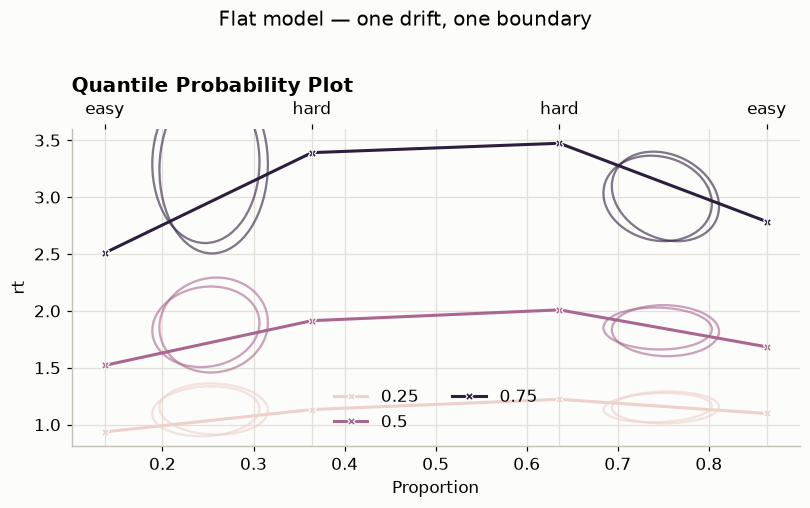

In [10]:
model_flat.sample_posterior_predictive(kind="response", draws=100)
model_flat.plot_quantile_probability(cond="cond", predictive_style="ellipse",
                                     ellipse_confidence=0.95)
plt.gcf().set_size_inches(7.5, 4.5)
plt.gcf().suptitle("Flat model — one drift, one boundary", y=1.02)
plt.tight_layout()

The **model cartoon** draws the fitted process itself: boundaries, start
point, drift and non-decision time, with the observed RT histograms mirrored
above and below.

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


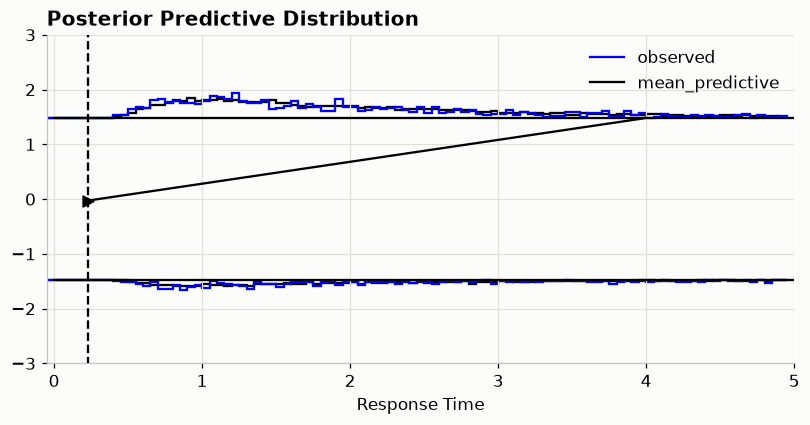

In [11]:
hssm.plotting.plot_model_cartoon(model_flat, n_samples=5)
plt.gcf().set_size_inches(7.5, 4)
plt.tight_layout()

## 5. The model the data deserves

The flat model has one drift and one boundary for every trial, but we built
this dataset so that drift depends on `cond` and boundary tracks `theta`.
In HSSM that is a formula per parameter — the bambi idea, applied to the
inside of a cognitive model.

Model initialized successfully.


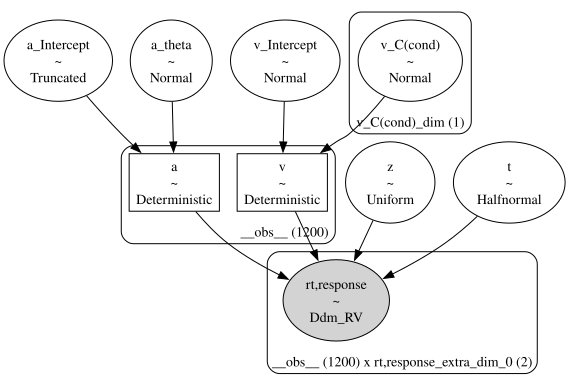

In [12]:
model_reg = hssm.HSSM(
    data=data, model="ddm",
    include=[{"name": "v", "formula": "v ~ 1 + C(cond)"},
             {"name": "a", "formula": "a ~ 1 + theta"}],
    p_outlier=0.05,
)
model_reg.graph()

In [13]:
model_reg.sample(draws=500, tune=500, chains=2, cores=1,
                 random_seed=RANDOM_SEED, progressbar=False)
print(az.summary(model_reg.traces,
                 var_names=["v_Intercept", "v_C(cond)", "a_Intercept",
                            "a_theta", "z", "t"],
                 kind="stats").to_string())
print("\nTRUE:", {k: v for k, v in TRUE.items()})

Using default initvals. 



Initializing NUTS using adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [t, z, v_Intercept, v_C(cond), a_Intercept, a_theta]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 8 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


                  mean     sd eti89_lb eti89_ub
v_Intercept       0.67  0.039      0.6     0.73
v_C(cond)[hard]  -0.44  0.045    -0.52    -0.37
a_Intercept        1.5  0.023      1.5      1.5
a_theta           0.27  0.017     0.24     0.29
z                 0.49  0.011     0.47     0.51
t                  0.3  0.015     0.27     0.32

TRUE: {'v_Intercept': 0.6, 'v_C(cond)': [-0.4], 'a_Intercept': 1.5, 'a_theta': 0.3, 'z': 0.5, 't': 0.3}


dt=None, we use the traces assigned to the HSSM object as datatree.


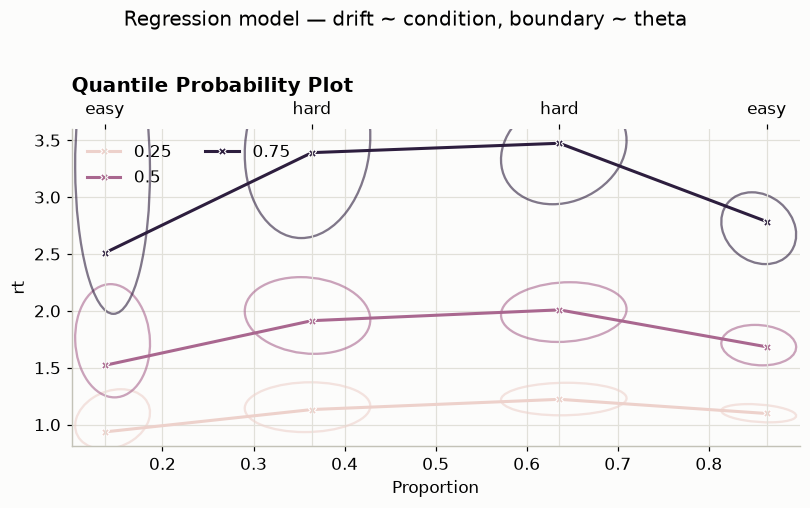

In [14]:
model_reg.sample_posterior_predictive(kind="response", draws=100)
model_reg.plot_quantile_probability(cond="cond", predictive_style="ellipse",
                                    ellipse_confidence=0.95)
plt.gcf().set_size_inches(7.5, 4.5)
plt.gcf().suptitle("Regression model — drift ~ condition, boundary ~ theta", y=1.02)
plt.tight_layout()

### How to read a quantile probability plot

This is the standard fit check for sequential-sampling models, and it is worth
learning to read properly because it shows accuracy and RT *at the same time*.

- **Horizontal axis** — the proportion of responses in that group. Each
  condition contributes **two** points: its errors on the left, its correct
  responses on the right, mirrored about 0.5.
- **Vertical axis** — RT quantiles. The three lines are the 25th, 50th and
  75th percentiles, so the vertical spread *is* the shape of the RT
  distribution.
- **Ellipses** — the posterior predictive. The model fits where they cover the
  observed points.

So the four x-positions read outward from the centre as: hard errors, hard
correct, easy errors, easy correct. **Because difficulty acts on the drift,
the conditions land at genuinely different proportions** — easy near 0.14 and
0.86, hard near 0.36 and 0.64 — which is what gives the plot its
characteristic inverted-U and makes the fit checkable at all.

Compare it with the flat model's plot above: that one collapses both
conditions onto a single pair of positions, because a single drift cannot
produce two accuracies.

<details class="sbi-tip">
<summary>💡 <b>This is the whole argument for HSSM</b></summary>

`include=[{"name": "v", "formula": "v ~ 1 + C(cond)"}]` replaced the
`v[coh_idx]` indexing you wrote by hand yesterday — and it extends to random
effects, multiple parameters, and link functions without you writing any of
it.

</details>

### Exercise

Fit a model where the mapping is **swapped**: drift depends on `theta` and
boundary on `cond`. It has exactly the same number of parameters. Compare its
quantile probability plot to the one above, and predict first — which of the
two axes of the plot will it get wrong?

<details>
<summary>What to notice</summary>

```python
swapped = hssm.HSSM(
    data=data, model="ddm",
    include=[{"name": "v", "formula": "v ~ 1 + theta"},
             {"name": "a", "formula": "a ~ 1 + C(cond)"}])
swapped.sample(draws=500, tune=500, chains=2, cores=1, progressbar=False)
swapped.sample_posterior_predictive(kind="response", draws=100)
swapped.plot_quantile_probability(cond="cond", predictive_style="ellipse")
```

The **horizontal** axis is the one that collapses. Boundary height barely
moves accuracy when the start point is unbiased — raising `a` makes both
responses slower and leaves their *ratio* almost untouched — so a model that
puts the condition effect on `a` predicts the two conditions at nearly the
same proportion. Its predicted ellipses stack up in two vertical columns while
the observed points sit at four clearly separated positions.

It still fits far better than the flat model, and it has the right number of
parameters. That is the trap: **the right number of parameters is not the same
as the right model**, and a summary table of coefficients will not tell you —
the fit check will.

This is also a design lesson, not only a modelling one. If your manipulation
only ever moves the boundary, a quantile probability plot has almost no
horizontal spread to check against, and you have thrown away the axis that
makes the model falsifiable.

</details>

## 6. *Optional* — hierarchical regression

Real designs have participants. HSSM takes bambi's random-effects syntax
directly, so a participant-level drift intercept is `(1|participant_id)`.

Model initialized successfully.


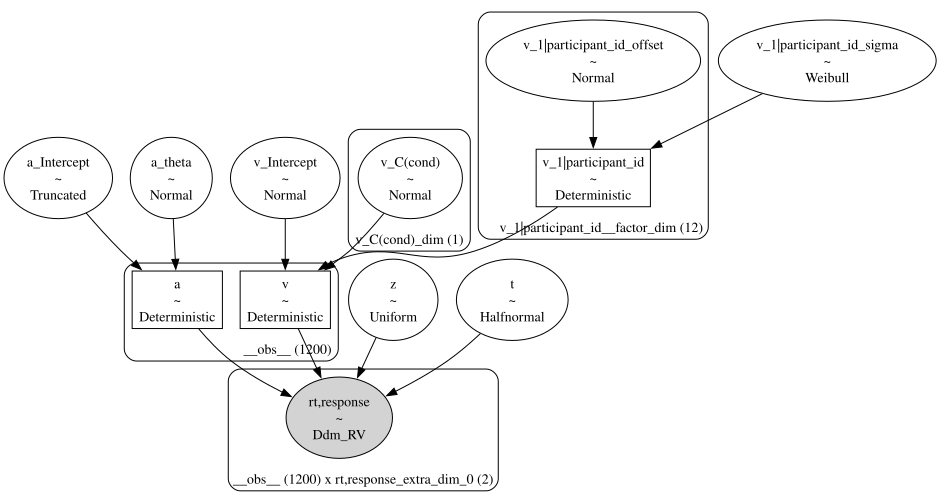

In [15]:
model_hier = hssm.HSSM(
    data=data, model="ddm",
    include=[{"name": "v", "formula": "v ~ 1 + C(cond) + (1|participant_id)"},
             {"name": "a", "formula": "a ~ 1 + theta"}],
    noncentered=True,          # see Day 3, 11:00 for why this matters
    p_outlier=0.05,
    prior_settings="safe",
)
model_hier.graph()

In [16]:
model_hier.sample(draws=500, tune=500, chains=2, cores=1,
                  random_seed=RANDOM_SEED, progressbar=False)
print(az.summary(model_hier.traces,
                 var_names=["v_Intercept", "v_C(cond)", "v_1|participant_id_sigma",
                            "a_Intercept", "a_theta"],
                 kind="stats").to_string())

Using default initvals. 



Initializing NUTS using adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [t, z, v_Intercept, v_C(cond), v_1|participant_id_sigma, v_1|participant_id_offset, a_Intercept, a_theta]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 30 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


                           mean     sd eti89_lb eti89_ub
v_Intercept                0.67  0.042      0.6     0.74
v_C(cond)[hard]           -0.45  0.045    -0.52    -0.38
v_1|participant_id_sigma  0.039  0.025   0.0072    0.085
a_Intercept                 1.5  0.023      1.5      1.5
a_theta                    0.27  0.016     0.24     0.29


`v_1|participant_id_sigma` is the **population spread** of participant drift
intercepts. Our synthetic participants were assigned at random, so it should
be near zero — and a hierarchical model that correctly reports "there is no
participant variance here" is doing its job.

The geometry of that `sigma` parameter is what the 11:00 session is about.

## 7. *Optional* — bring your own likelihood

The likelihood does not have to be one of HSSM's. Anything you can write as a
**JAX function** works, which is the route to models HSSM has never heard of.

The contract: `f(data_i, *params) -> scalar`, where `data_i` is one trial's
`[rt, choice]`. HSSM `vmap`s it over trials and differentiates it for you.

As a stand-in for a trained network, here is a hand-written surrogate — a
lognormal RT crossed with a biased choice:

$$
\text{rt}_i \sim \text{LogNormal}\!\big(\mu(v,a,t),\ \sigma\big), \qquad
\mu = \log a - \log(v^2 + \tfrac14) + t,
$$
$$
P(\text{choice} = +1) = \operatorname{logit}^{-1}\!\big(2va + 4(z - \tfrac12)\big).
$$

Both the location of the RT distribution and the choice probability depend on
the parameters, so all four are doing something.

In [17]:
import jax.numpy as jnp
from functools import partial
from hssm.config import ModelConfig
from ssms.hssm_support import decorate_atomic_simulator, hssm_sim_wrapper

SIGMA = 0.45


def surrogate_logp(data, v, a, z, t):
    """Single-trial log density of the surrogate above."""
    # Force scalars. HSSM hands regression-capable parameters through as
    # length-1 arrays; returning a (1,) instead of a () silently multiplies the
    # total log-likelihood by the number of observations.
    v, a, z, t = (jnp.reshape(p, ()) for p in (v, a, z, t))
    rt, ch = data[0], data[1]

    mu = jnp.log(a) - jnp.log(v**2 + 0.25) + t
    log_rt = jnp.log(jnp.maximum(rt, 1e-6))
    logp_rt = (-log_rt - jnp.log(SIGMA) - 0.5 * jnp.log(2 * jnp.pi)
               - 0.5 * ((log_rt - mu) / SIGMA) ** 2)

    drive = 2.0 * v * a + 4.0 * (z - 0.5)
    p_up = 1.0 / (1.0 + jnp.exp(-drive))
    logp_ch = jnp.where(ch > 0, jnp.log(p_up), jnp.log1p(-p_up))
    return logp_rt + logp_ch


def surrogate_sim(theta, model=None, n_samples=1, random_state=None, **kwargs):
    """The generative twin of `surrogate_logp` — same maths, forwards."""
    rng = np.random.default_rng(random_state)
    theta = np.atleast_2d(np.asarray(theta, dtype=np.float64))
    v, a, z, t = theta[:, 0], theta[:, 1], theta[:, 2], theta[:, 3]
    mu = np.log(a) - np.log(v**2 + 0.25) + t
    p_up = 1.0 / (1.0 + np.exp(-(2.0 * v * a + 4.0 * (z - 0.5))))
    shape = (n_samples, theta.shape[0])
    rts = np.exp(rng.normal(mu, SIGMA, size=shape))[..., None].astype(np.float32)
    ch = np.where(rng.random(shape) < p_up, 1, -1)[..., None].astype(np.int32)
    if n_samples == 1:
        rts, ch = rts[0], ch[0]
    return {"rts": rts, "choices": ch}


# Wrapping the simulator so HSSM can use it as the model's random variable.
surrogate_rv = decorate_atomic_simulator(
    model_name="surrogate", choices=[-1, 1], obs_dim=2
)(partial(hssm_sim_wrapper, simulator_fun=surrogate_sim, model="surrogate"))

surrogate_cfg = ModelConfig(
    response=["rt", "response"],
    list_params=["v", "a", "z", "t"],
    choices=(-1, 1),
    bounds={"v": (-3.0, 3.0), "a": (0.3, 2.5), "z": (0.1, 0.9), "t": (0.0, 1.0)},
    backend="jax",
    rv=surrogate_rv,          # <- without this there is no posterior predictive
)

Simulate from it at known parameters, then try to recover them.

In [18]:
TRUE_SUR = dict(v=0.9, a=1.3, z=0.5, t=0.3)
sur_data = pd.DataFrame(
    surrogate_rv(theta=np.tile([TRUE_SUR[p] for p in PARAMS], (1500, 1)),
                 n_replicas=1, random_state=RANDOM_SEED),
    columns=["rt", "response"])

model_sur = hssm.HSSM(data=sur_data, model="surrogate", model_config=surrogate_cfg,
                      loglik=surrogate_logp, loglik_kind="approx_differentiable",
                      p_outlier=0)
model_sur.sample(sampler="numpyro", draws=500, tune=500, chains=2, cores=1,
                 random_seed=RANDOM_SEED, progressbar=False)
print(az.summary(model_sur.traces, var_names=PARAMS, kind="stats").to_string())
print("\nTRUE:", TRUE_SUR)

Model initialized successfully.


Using default initvals. 



NUTS[numpyro]: [t, a, z, v]


There were 317 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


   mean    sd eti89_lb eti89_ub
v  0.84  0.14     0.62      1.1
a   1.4  0.33     0.83      1.9
z  0.54  0.23     0.16     0.87
t  0.17   0.1     0.02     0.33

TRUE: {'v': 0.9, 'a': 1.3, 'z': 0.5, 't': 0.3}


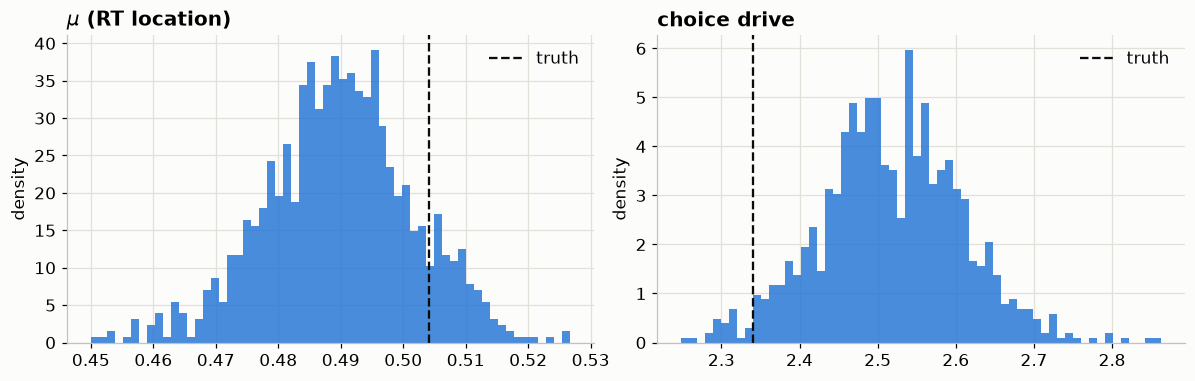

In [19]:
po = model_sur.traces.posterior
v_, a_, z_, t_ = (po[p].values.ravel() for p in PARAMS)
mu_post = np.log(a_) - np.log(v_**2 + 0.25) + t_
drive_post = 2 * v_ * a_ + 4 * (z_ - 0.5)
mu_true = np.log(1.3) - np.log(0.9**2 + 0.25) + 0.3
drive_true = 2 * 0.9 * 1.3 + 4 * (0.5 - 0.5)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, vals, truth, name in [(axes[0], mu_post, mu_true, r"$\mu$ (RT location)"),
                              (axes[1], drive_post, drive_true, "choice drive")]:
    ax.hist(vals, bins=60, density=True, color=S.PRIMARY, alpha=0.85)
    S.truth_line(ax, truth, axis="x")
    ax.set(title=name, ylabel="density")
    ax.legend()
fig.tight_layout()

The individual parameters are recovered only loosely, and the two derived
quantities above show why: the data constrain the RT **location** $\mu$ and
the **choice drive**, and several $(v, a, z, t)$ combinations give the same
pair. That is the identifiability lesson from yesterday afternoon, arriving
uninvited in a model we wrote ourselves.

Because we attached `rv=`, posterior predictive sampling works too:

In [20]:
model_sur.sample_posterior_predictive(draws=100)
pp = model_sur.traces["posterior_predictive"]["rt,response"].values
print(f"predicted mean rt {pp[..., 0].mean():.3f} (observed {sur_data.rt.mean():.3f})")
print(f"predicted P(+1)   {(pp[..., 1] > 0).mean():.3f} "
      f"(observed {(sur_data.response > 0).mean():.3f})")

dt=None, we use the traces assigned to the HSSM object as datatree.


predicted mean rt 1.803 (observed 1.811)
predicted P(+1)   0.926 (observed 0.925)


## 8. *Optional* — a likelihood learned by BayesFlow

The surrogate above was hand-written. In practice you would **train** one:
simulate from a model that has no closed-form likelihood, learn the density
with a normalizing flow, and hand the trained network to HSSM as the same
kind of JAX callable.

The full recipe is below. It trains in about a minute; in a real project you
would train once and save the network.

```python
import os
os.environ["KERAS_BACKEND"] = "jax"       # BEFORE importing keras / bayesflow
import bayesflow as bf

# 1. simulate training data across the parameter box you want to support
LOW  = np.array([-2.5, 0.5, 0.3, 0.0])    # this box IS the network's validity region
HIGH = np.array([ 2.5, 2.0, 0.7, 1.0])
theta = rng.uniform(LOW, HIGH, size=(4000, 4))
out = simulator(theta=theta, model="ddm", n_samples=10, random_state=0)

# 2. train a coupling flow to learn p(rt, choice | theta)
workflow = bf.BasicWorkflow(
    inference_network=bf.networks.CouplingFlow(depth=6),
    standardize=None,                     # load-bearing — see below
    ...)
workflow.fit_offline({"inference_variables": x, "inference_conditions": theta_n},
                     epochs=60)

# 3. the trained flow's log_prob IS a JAX function
net = workflow.approximator.inference_network

def trained_logp(data, v, a, z, t):
    theta_n = normalise(jnp.stack([v, a, z, t]))
    x = jnp.stack([standardise_rt(data[0]), data[1]])
    return net.log_prob(x[None, :], conditions=theta_n[None, :])[0]

# 4. hand it to HSSM exactly like the surrogate above
hssm.HSSM(data=..., model="learned", model_config=cfg,
          loglik=trained_logp, loglik_kind="approx_differentiable")

# 5. save it so you never train twice
workflow.approximator.save("ddm_nle.keras")     # ~4 MB, reloads in under a second
```

<details class="sbi-warn" open>
<summary>⚠️ <b>Three traps on this route, all silent</b></summary>

**Use `approximator.inference_network.log_prob`, not
`approximator.log_prob`.** The latter is the documented user-facing call and
is *not* JAX-traceable — it converts to numpy internally and dies under
`jit`/`grad` with a `TracerArrayConversionError`.

**Set `standardize=None`.** With BayesFlow's default the raw network log-density
is missing the standardization and its log-determinant, so the likelihood is
wrong by a data-dependent amount, with no error.

**The training box is the validity region.** Outside it the network
extrapolates and returns confident nonsense. Set `bounds` in the `ModelConfig`
to the box you trained on, and keep priors inside it.

</details>

## What to take away

<details class="sbi-tip">
<summary>💡 <b>The five things that matter</b></summary>


1. **HSSM is bambi for cognitive models.** A formula per *SSM parameter*,
   instead of `v[coh_idx]` by hand.
2. **`print(model)` and `model.graph()` before you sample.** They resolve every
   prior, bound, link and the lapse process.
3. **`p_outlier` is on by default at 0.05.** It is a robustifying floor on the
   likelihood, it is a modelling assumption, and you should report it.
4. **Check the fit with SSM-specific plots** — quantile probability and the
   model cartoon — not just traces.
5. **Any JAX function can be the likelihood.** Attach an `rv=` too, or you
   lose posterior predictive sampling.

</details>

### Quick reference

| want to | call |
|---|---|
| a model | `hssm.HSSM(data=df, model="ddm")` |
| check what you built | `print(model)` · `model.graph()` |
| a regression on a parameter | `include=[{"name": "v", "formula": "v ~ 1 + x"}]` |
| participant effects | `"v ~ 1 + x + (1\|participant_id)"`, `noncentered=True` |
| no lapse process | `p_outlier=None` |
| summarise | `az.summary(model.traces, var_names=[...])` |
| SSM fit check | `model.plot_quantile_probability(cond=..., predictive_style="ellipse")` |
| see the process | `hssm.plotting.plot_model_cartoon(model)` |
| known-truth data | `model.sample_do({...}, draws=1)` |
| your own likelihood | `loglik=<jax fn>`, `loglik_kind="approx_differentiable"`, `rv=<sim>` |

**Next, at 11:00:** the `sigma` in `(1|participant_id)` has a posterior
geometry that will break your sampler if you let it.